In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import joblib

 

In [2]:
# Load the dataset
print("Loading data...")
df = pd.read_csv('Fraud.csv')
print(f"Data loaded successfully. Shape: {df.shape}")

Loading data...
Data loaded successfully. Shape: (6362620, 11)


In [3]:
print("Engineering features...")

# 1. Calculate the mathematical errors in the balances
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# 2. Drop irrelevant columns
# 'nameOrig' and 'nameDest' are strings/identifiers. 
# 'isFlaggedFraud' is a static, inaccurate rule from the original dataset.
df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True)

# 3. One-Hot Encode the 'type' column (CASH_OUT, TRANSFER, etc.)
df = pd.get_dummies(df, columns=['type'], drop_first=True)

print(f"Feature engineering complete. New shape: {df.shape}")

Engineering features...
Feature engineering complete. New shape: (6362620, 13)


In [4]:
print("Splitting data...")
X = df.drop(columns=['isFraud'])
y = df['isFraud']

# 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Delete the original dataframe to free up RAM!
 
print("Data split complete.")

Splitting data...
Data split complete.


In [5]:
print("Training HistGradientBoostingClassifier...")

# Initialize the model
# We do NOT use class_weight='balanced' to protect our precision!
hgb_model = HistGradientBoostingClassifier(
    max_iter=100,          # Number of boosting iterations (trees)
    max_depth=12,          # Keep trees from growing too deep
    learning_rate=0.1,     # Standard learning rate
    random_state=42
)

# Fit the model
hgb_model.fit(X_train, y_train)
print("Model training complete.")

Training HistGradientBoostingClassifier...
Model training complete.


In [6]:
print("Evaluating model...")

# Generate predictions
y_pred = hgb_model.predict(X_test)
y_pred_proba = hgb_model.predict_proba(X_test)[:, 1]

# 1. Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"True Negatives: {cm[0][0]} (Legitimate transactions approved)")
print(f"False Positives: {cm[0][1]} (Legitimate transactions blocked - WE WANT THIS LOW)")
print(f"False Negatives: {cm[1][0]} (Fraud missed)")
print(f"True Positives: {cm[1][1]} (Fraud caught)")

 

Evaluating model...

--- Confusion Matrix ---
[[1906304      18]
 [      9    2455]]
True Negatives: 1906304 (Legitimate transactions approved)
False Positives: 18 (Legitimate transactions blocked - WE WANT THIS LOW)
False Negatives: 9 (Fraud missed)
True Positives: 2455 (Fraud caught)



--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.99      1.00      0.99      2464

    accuracy                           1.00   1908786
   macro avg       1.00      1.00      1.00   1908786
weighted avg       1.00      1.00      1.00   1908786


--- PR-AUC Score: 0.9952 ---


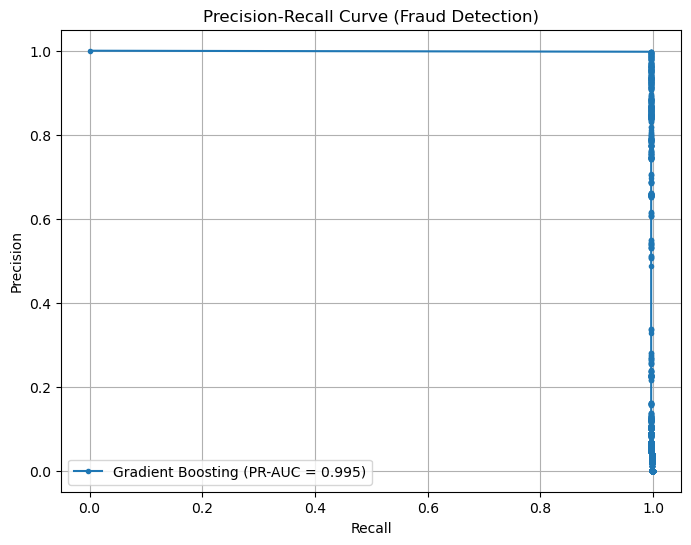

In [7]:
# 2. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
print(f"\n--- PR-AUC Score: {pr_auc:.4f} ---")

# 4. Plot the PR Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'Gradient Boosting (PR-AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Fraud Detection)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import os

print("Saving model...")
os.makedirs("models", exist_ok=True)

# Save the trained model
joblib.dump(hgb_model, "models/fraud_hgb_model.pkl")
print("Model saved successfully in the 'models' folder!")

Saving model...
Model saved successfully in the 'models' folder!
